<a href="https://colab.research.google.com/github/VorisbekErnazarov/Machine-Learning-projects/blob/main/forest_non_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# import libraries
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [4]:
# load data
with rasterio.open('/content/drive/MyDrive/Internship_Uzcosmos/datasets/chimgan_dataset_final_fixed.tif') as src:
    print(f'Number of bands: {src.count}')
    print(f'Image size {src.width} rows x {src.height} columns')

    data = src.read().astype(float)

print(f"Data shape: {data.shape}")
print("Min:", np.nanmin(data))
print('Max: ', np.nanmax(data))


band_names = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'VV', 'VH', 'treecover']
for i in range(data.shape[0]):
  band = data[i]
  print(f'Band {i} ({band_names[i]}): min={np.nanmin(band)}, max={np.nanmax(band)}')



Number of bands: 9
Image size 3711 rows x 1861 columns
Data shape: (9, 1861, 3711)
Min: -30.73220443725586
Max:  15230.0
Band 0 (B2): min=0.0, max=11552.0
Band 1 (B3): min=0.0, max=13113.0
Band 2 (B4): min=0.0, max=14514.0
Band 3 (B8): min=0.0, max=14335.0
Band 4 (B11): min=121.0, max=15230.0
Band 5 (B12): min=99.0, max=15153.0
Band 6 (VV): min=-25.41999053955078, max=13.961620330810547
Band 7 (VH): min=-30.73220443725586, max=3.1598622798919678
Band 8 (treecover): min=0.0, max=100.0


In [24]:
# Normalize data B2, B3, B4, B8, B11, B12
normalized_data = data[0:6] / 10000.0

B2 = normalized_data[0]
B3 = normalized_data[1]
B4 = normalized_data[2]
B8 = normalized_data[3]
B11 = normalized_data[4]
B12 = normalized_data[5]

vv = data[6]
vh = data[7]

# linear
vv_lin = 10 ** (vv / 10)
vh_lin = 10 ** (vh / 10)

# ratio
vh_vv_ratio = np.where(vv_lin > 1e-6, vh_lin / vv_lin, 0)
vh_vv_ratio = np.clip(vh_vv_ratio, 0, 5)

# difference
vv_vh_diff = vh - vv

# treecover
treecover = data[8] / 100.0

# compute ndvi
ndvi = np.where((B8 + B4) > 0, (B8 - B4) / (B8 + B4), 0)
ndvi = np.clip(ndvi, -1, 1)

# compute evi
evi = np.where((B8 + 6*B4 - 7.5*B2 +1) > 0, 2.5 * (B8 - B4) / (B8 + 6 * B4 - 7.5 * B2 + 1), 0)
evi = np.clip(evi, -1, 1)

# compute ndmi
ndmi = np.where((B8 + B11) > 0, (B8 - B11) / (B8 + B11), 0)
ndmi = np.clip(ndmi, -1, 1)


print(f"NDVI range: {ndvi.min():.3f} to {ndvi.max():.3f}")
print(f"EVI range: {evi.min():.3f} to {evi.max():.3f}")
print(f"NDMI range: {ndmi.min():.3f} to {ndmi.max():.3f}")
print(f"VH/VV range: {vh_vv_ratio.min():.3f} to {vh_vv_ratio.max():.3f}")

NDVI range: -1.000 to 1.000
EVI range: -1.000 to 1.000
NDMI range: -1.000 to 0.939
VH/VV range: 0.000 to 2.943


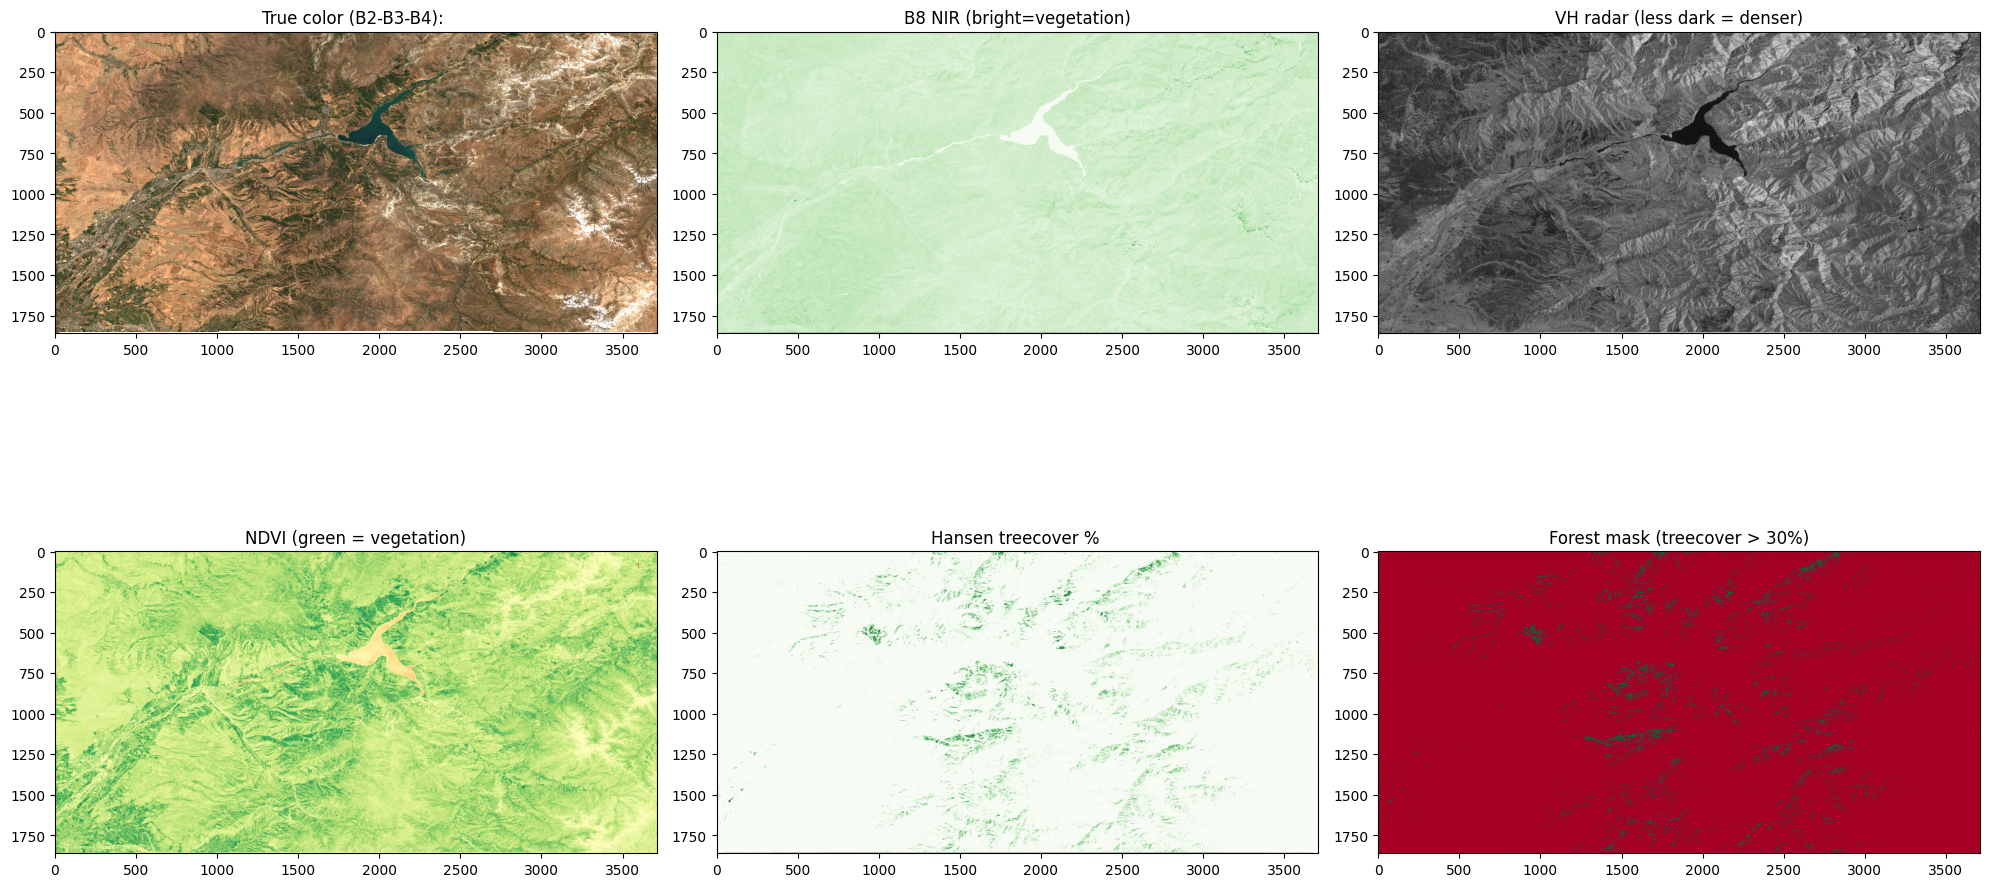

In [25]:
rows, cols = B2.shape

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# true color rgb
rgb = np.stack([B4, B3, B2], axis=-1)
rgb = np.clip(rgb * 3.5, 0, 1)
axes[0, 0].imshow(rgb)
axes[0, 0].set_title("True color (B2-B3-B4): ")

# NIR
axes[0, 1].imshow(B8, cmap='Greens')
axes[0, 1].set_title('B8 NIR (bright=vegetation)')

# VH radar
axes[0, 2].imshow(vh, cmap='gray')
axes[0, 2].set_title('VH radar (less dark = denser)')

# show ndvi
axes[1, 0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 0].set_title("NDVI (green = vegetation)")

# treecover
axes[1, 1].imshow(treecover * 100, cmap='Greens', vmin=0, vmax=100)
axes[1, 1].set_title('Hansen treecover % ')

# treecover binary mask
binary = (treecover * 100 > 30).astype(int)
axes[1, 2].imshow(binary, cmap='RdYlGn')
axes[1, 2].set_title("Forest mask (treecover > 30%)")

plt.tight_layout()
plt.savefig('visualization.png', dpi=150)
plt.show()

Forest pixels: 192,540
Non forest pixels: 6,695,857
Forest fraction: 2.79%


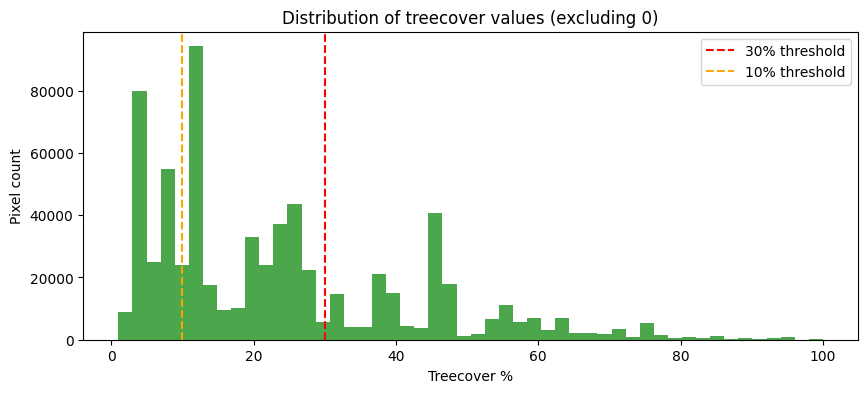

In [11]:
# check data
print(f"Forest pixels: {(treecover  * 100 > 30).sum():,}")
print(f"Non forest pixels: {(treecover * 100 <= 30).sum():,}")
print(f"Forest fraction: {(treecover * 100 > 30).mean():.2%}")

plt.figure(figsize=(10, 4))
plt.hist(treecover[treecover > 0] * 100, bins=50, color='green', alpha=0.7)
plt.xlabel('Treecover %')
plt.ylabel('Pixel count')
plt.title('Distribution of treecover values (excluding 0)')
plt.axvline(30, color='red', linestyle='--', label='30% threshold')
plt.axvline(10, color='orange', linestyle='--', label='10% threshold')
plt.legend()
plt.show()

In [28]:
# target
treecover_pict = treecover * 100
mask = np.full(treecover_pict.shape, 255, dtype=np.uint8)

mask[treecover_pict >= 40] = 1
mask[treecover_pict < 10] = 0

print(f"Uncertain forest: {(mask == 255).sum():,}")

Uncertain forest: 388,697


In [26]:
# Feature matrix X ni qurish
X = np.column_stack([
    B2.ravel(),   # Blue
    B3.ravel(),   # Green
    B4.ravel(),   # Red
    B8.ravel(),   # NIR
    B11.ravel(),  # SWIR1
    B12.ravel(),  # SWIR2
    vv.ravel(),
    vh.ravel(),
    vv_lin.ravel(),
    vh_lin.ravel(),
    vh_vv_ratio.ravel(),
    vv_vh_diff.ravel(),
    ndvi.ravel(),
    evi.ravel(),
    ndmi.ravel()
])

print(f"X matritsasi shakli: {X.shape}")

X matritsasi shakli: (6906171, 15)


In [39]:
# create labels and filter like take only valid
mask_flat = mask.ravel()
valid = mask_flat != 255

X_labelled = X[valid]
y_labelled = mask_flat[valid]

print(f" Sum of labelled pixels: {len(y):,}")
print(f"Forest: {(y==1).sum():,}")
print(f"Non forest: {(y==0).sum():,}")
print(f"Forest fraction: {y.mean():.2%}")

 Sum of labelled pixels: 6,517,474
Forest: 134,810
Non forest: 6,382,664
Forest fraction: 2.07%


In [42]:
# balance data and split train/test
forest_indices = np.where(y==1)[0]
nonforest_indices = np.where(y==0)[0]

print(f"\nBefore balancing:")
print(f"Forest samples: {len(forest_indices):,}")
print(f"Non forest samples: {(len(nonforest_indices)):,}")


np.random.seed(42)
nonforest_samples = np.random.choice(
    nonforest_indices,
    size=len(forest_indices),
    replace=False
)

# combine and shuffle
idx_balanced = np.concatenate([forest_indices, nonforest_samples])
np.random.shuffle(idx_balanced)

X_balanced = X_labelled[idx_balanced]
y_balanced = y_labelled[idx_balanced]

print(f"\nAfter balancing: ")
print(f"Forest: {(y_balanced==1).sum():,}")
print(f"Non forest: {(y_balanced == 0).sum():,}")


# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# show data for train and test
print(f"Train: {len(X_train):,}")
print(f"Test: {len(X_test):,}")


Before balancing:
Forest samples: 134,810
Non forest samples: 6,382,664

After balancing: 
Forest: 134,810
Non forest: 134,810
Train: 215,696
Test: 53,924


In [45]:
# select model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# train model
model.fit(X_train, y_train)
print("Train completed")

Train completed


In [48]:
# make predictions
y_prediction = model.predict(X_test)

print(classification_report(y_test, y_prediction))
print(f"Accuracy score: {accuracy_score(y_test, y_prediction)}")

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     26962
           1       0.88      0.92      0.90     26962

    accuracy                           0.89     53924
   macro avg       0.89      0.89      0.89     53924
weighted avg       0.89      0.89      0.89     53924

Accuracy score: 0.8938320599362065
